# YOLOv8 Ensemble Training + Evaluation + WBF (Colab Ready)

## 1. Mount Google Drive

In [1]:
# ============================================
# STEP 1: Mount Google Drive
# ============================================
from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive mounted")

Mounted at /content/drive
✅ Google Drive mounted


In [2]:
# ============================================
# STEP 2: Setup Dataset from Shared Google Drive
# ============================================
import os
import shutil
import yaml

# ========== OPTION A: Add Shortcut to Your Drive (RECOMMENDED) ==========
# 1. Open this link in browser: https://drive.google.com/drive/folders/1Lpc7CGaUDzfXi10IfAZE0YwxT5IbEcyi
# 2. Right-click on the folder → "Organize" → "Add shortcut" → "My Drive"
# 3. Run this cell - it will find the shortcut automatically

DRIVE_DATASET_PATH = None  # Will auto-detect

# Destination in Colab (LOCAL - writable)
DATASET_PATH = "/content/yolo_dataset"

print("="*60)
print("SETTING UP DATASET")
print("="*60)

# Auto-detect dataset location in Drive
if DRIVE_DATASET_PATH is None:
    possible_paths = [
        "/content/drive/MyDrive/yolo_dataset",
        "/content/drive/MyDrive/Yolo_dataset",
        "/content/drive/MyDrive/YOLO_dataset",
        "/content/drive/MyDrive/yolo dataset",
        "/content/drive/Shareddrives/yolo_dataset",
    ]

    for path in possible_paths:
        if os.path.exists(path) and os.path.exists(f"{path}/data.yaml"):
            DRIVE_DATASET_PATH = path
            print(f"✅ Auto-detected dataset at: {path}")
            break

if DRIVE_DATASET_PATH and os.path.exists(DRIVE_DATASET_PATH):
    print(f"\nCopying dataset from Drive to local Colab storage...")
    print(f"From: {DRIVE_DATASET_PATH}")
    print(f"To: {DATASET_PATH}")

    # Remove old dataset if exists
    if os.path.exists(DATASET_PATH):
        shutil.rmtree(DATASET_PATH)

    # Copy to local storage (faster for training)
    shutil.copytree(DRIVE_DATASET_PATH, DATASET_PATH)

    # ====== CRITICAL FIX: Update data.yaml to use LOCAL paths ======
    print("\n🔧 Fixing data.yaml paths...")
    data_yaml_path = f"{DATASET_PATH}/data.yaml"

    # Read original data.yaml
    with open(data_yaml_path, 'r') as f:
        data_config = yaml.safe_load(f)

    print(f"   Original config: {data_config}")

    # Update paths to local
    data_config['path'] = DATASET_PATH
    data_config['train'] = 'train/images'
    data_config['val'] = 'valid/images'
    data_config['test'] = 'test/images'

    # Write fixed data.yaml
    with open(data_yaml_path, 'w') as f:
        yaml.dump(data_config, f, default_flow_style=False)

    print(f"   Fixed config: {data_config}")

    # ====== Remove old cache files (they reference wrong paths) ======
    print("\n🧹 Removing old cache files...")
    for root, dirs, files in os.walk(DATASET_PATH):
        for file in files:
            if file.endswith('.cache'):
                cache_path = os.path.join(root, file)
                os.remove(cache_path)
                print(f"   Removed: {cache_path}")

    print("\n✅ Dataset setup complete!")
else:
    print("❌ Dataset not found in Google Drive!")
    print("\nPlease add a shortcut to the shared folder in your Drive")

# Verify dataset structure
print("\n" + "-"*60)
print("Dataset contents:")
print("-"*60)
if os.path.exists(DATASET_PATH):
    !ls -la {DATASET_PATH}

    print("\n📄 data.yaml contents:")
    !cat {DATASET_PATH}/data.yaml

    # Check essential folders
    essential = ["train", "valid", "test", "data.yaml"]
    print("\nChecking essential files:")
    for item in essential:
        path = f"{DATASET_PATH}/{item}"
        if os.path.exists(path):
            print(f"  ✅ {item}")
        else:
            print(f"  ❌ {item} - MISSING")

SETTING UP DATASET
✅ Auto-detected dataset at: /content/drive/MyDrive/yolo_dataset

Copying dataset from Drive to local Colab storage...
From: /content/drive/MyDrive/yolo_dataset
To: /content/yolo_dataset

🔧 Fixing data.yaml paths...
   Original config: {'train': 'train/images', 'val': 'valid/images', 'test': 'test/images', 'nc': 6, 'names': ['Customer-Bagpack', 'Product', 'Product-Picked', 'Shopping-Cart', 'normal', 'theft'], 'roboflow': {'license': 'CC BY 4.0', 'project': 'cc-tv-footage-annotation-b8-lcysc-b1-wutkr', 'url': 'https://universe.roboflow.com/grad-lnwh2/cc-tv-footage-annotation-b8-lcysc-b1-wutkr/dataset/2', 'version': 2, 'workspace': 'grad-lnwh2'}}
   Fixed config: {'train': 'train/images', 'val': 'valid/images', 'test': 'test/images', 'nc': 6, 'names': ['Customer-Bagpack', 'Product', 'Product-Picked', 'Shopping-Cart', 'normal', 'theft'], 'roboflow': {'license': 'CC BY 4.0', 'project': 'cc-tv-footage-annotation-b8-lcysc-b1-wutkr', 'url': 'https://universe.roboflow.com/gra

In [3]:
!mkdir -p /content/drive/MyDrive/yolo_ensemble_project


In [ ]:
# !mv /content/drive/MyDrive/yolo_dataset/yolo_ensemble/yolov8n \
#     /content/drive/MyDrive/yolo_ensemble_project/


mv: cannot stat '/content/drive/MyDrive/yolo_dataset/yolo_ensemble/yolov8n': No such file or directory


In [ ]:
# !mv /content/drive/MyDrive/yolo_dataset/yolo_ensemble/yolov8s \
#     /content/drive/MyDrive/yolo_ensemble_project/


mv: cannot stat '/content/drive/MyDrive/yolo_dataset/yolo_ensemble/yolov8s': No such file or directory


In [ ]:
# !mv /content/drive/MyDrive/yolo_dataset/yolo_ensemble/yolov8m \
#     /content/drive/MyDrive/yolo_ensemble_project/


mv: cannot stat '/content/drive/MyDrive/yolo_dataset/yolo_ensemble/yolov8m': No such file or directory


In [ ]:
# !ls /content/drive/MyDrive/yolo_ensemble_project


In [ ]:
# %cd /content/drive/MyDrive/yolo_dataset
# !ls


/content/drive/.shortcut-targets-by-id/1Lpc7CGaUDzfXi10IfAZE0YwxT5IbEcyi/yolo_dataset
data.yaml	     runs   valid		   yolov8n.pt
README.dataset.txt   test   yolo_ensemble
README.roboflow.txt  train  yolo_ensemble_project


## 2. Install Dependencies

In [4]:
!pip install ultralytics ensemble-boxes supervision opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.4/212.4 kB 26.5 MB/s eta 0:00:00


## 3. Imports

In [5]:

from ultralytics import YOLO
import torch, os
from ensemble_boxes import weighted_boxes_fusion


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 4. Check GPU

In [6]:
!nvidia-smi


Fri Jan 23 21:26:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


CUDA: True
Tesla T4


## 5. Dataset & Training Config

In [8]:
# ============================================
# GLOBAL CONFIGURATION - USE THESE EVERYWHERE
# ============================================

# Dataset path (downloaded from shared Google Drive folder)
DATASET_PATH = "/content/yolo_dataset"
DATA_YAML = f"{DATASET_PATH}/data.yaml"

# Training parameters
EPOCHS = 50
IMG_SIZE = 640
BATCH = 16
CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.5

# Paths for test evaluation
TEST_IMAGES_DIR = f"{DATASET_PATH}/test/images"
TEST_LABELS_DIR = f"{DATASET_PATH}/test/labels"
VALID_IMAGES_DIR = f"{DATASET_PATH}/valid/images"
VALID_LABELS_DIR = f"{DATASET_PATH}/valid/labels"

# Class names for the dataset
CLASS_NAMES = [
    "Customer-Bagpack",
    "Product",
    "Product-Picked",
    "Shopping-Cart",
    "Normal",
    "Theft"
]

# Verify paths exist
import os
print("Configuration loaded:")
print(f"  DATASET_PATH: {DATASET_PATH}")
print(f"  DATA_YAML: {DATA_YAML}")
print(f"  EPOCHS: {EPOCHS}")
print(f"  IMG_SIZE: {IMG_SIZE}")
print(f"  BATCH: {BATCH}")

# Verify dataset structure
print("\nVerifying dataset structure...")
for path in [DATA_YAML, TEST_IMAGES_DIR, TEST_LABELS_DIR, VALID_IMAGES_DIR]:
    if os.path.exists(path):
        print(f"  ✅ {path}")
    else:
        print(f"  ❌ {path} - NOT FOUND")

Configuration loaded:
  DATASET_PATH: /content/yolo_dataset
  DATA_YAML: /content/yolo_dataset/data.yaml
  EPOCHS: 50
  IMG_SIZE: 640
  BATCH: 16

Verifying dataset structure...
  ✅ /content/yolo_dataset/data.yaml
  ✅ /content/yolo_dataset/test/images
  ✅ /content/yolo_dataset/test/labels
  ✅ /content/yolo_dataset/valid/images


## 6. YOLO Ensemble Models

In [12]:

YOLO_MODELS = {
    "yolov8n": "yolov8n.pt",
    "yolov8s": "yolov8s.pt",
    "yolov8m": "yolov8m.pt"
}


## 7. Training Function

In [9]:
# NOTE: Using global DATA_YAML defined above - DO NOT redefine here
# This cell is kept for reference but uses global config
print(f"Using DATA_YAML: {DATA_YAML}")
print(f"Using EPOCHS: {EPOCHS}")
print(f"Using BATCH: {BATCH}")
print(f"Using IMG_SIZE: {IMG_SIZE}")

Using DATA_YAML: /content/yolo_dataset/data.yaml
Using EPOCHS: 50
Using BATCH: 16
Using IMG_SIZE: 640


In [10]:

def train_model(model_name, weights):
    model = YOLO(weights)
    model.train(
        data=DATA_YAML,
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH,
        device=0,
        project="yolo_ensemble",
        name=model_name
    )
    return model


## 8. Train Ensemble Models

In [13]:
from datetime import datetime
import platform
import os
from ultralytics import YOLO

# 1. Force working directory to /content
os.chdir("/content")

# ====== IMPORTANT: Save outputs to LOCAL storage ======
PROJECT_DIR = "/content/yolo_ensemble"

print("\n" + "="*70)
print("RESUMING ENSEMBLE TRAINING (Fixed Corrupt Download)")
print("="*70)

# Windows fix
if platform.system() == 'Windows':
    NUM_WORKERS = 0
else:
    NUM_WORKERS = 8

# Loop over ensemble models
for model_name, weights in YOLO_MODELS.items():

    # ====== STEP 1: SMART SKIP (Check if finished) ======
    final_weights_path = os.path.join(PROJECT_DIR, model_name, "weights", "best.pt")

    if os.path.exists(final_weights_path):
        print(f"\n✅ {model_name.upper()} already trained. Skipping...")
        continue

    # ====== STEP 2: FIX CORRUPT FILES ======
    # If the file exists but is empty/small (failed download), delete it.
    if os.path.exists(weights):
        if os.path.getsize(weights) < 1000000:  # Less than 1MB = corrupt
            print(f"⚠️ Found corrupt file {weights}. Deleting...")
            os.remove(weights)

    # ====== STEP 3: MANUAL DOWNLOAD (Working URL) ======
    if not os.path.exists(weights):
        print(f"📥 Downloading {weights} from valid source...")
        # Using v8.2.0 which is a stable release for these weights
        url = f"https://github.com/ultralytics/assets/releases/download/v8.2.0/{weights}"
        os.system(f"wget -O {weights} {url}")

    print("\n" + "-"*60)
    print(f"TRAINING MODEL: {model_name.upper()}")
    print("-"*60)

    # Load the model (Now guaranteed to be a valid file)
    try:
        model = YOLO(weights)
    except Exception as e:
        print(f"❌ Critical Error loading {weights}: {e}")
        # Last ditch: try downloading one more time if load fails
        os.system(f"rm {weights}")
        url = f"https://github.com/ultralytics/assets/releases/download/v8.2.0/{weights}"
        os.system(f"wget -O {weights} {url}")
        model = YOLO(weights)

    results = model.train(
        data=DATA_YAML,
        epochs=EPOCHS,
        batch=BATCH,
        imgsz=IMG_SIZE,
        device=0,

        # Hyperparameters
        optimizer='AdamW',
        lr0=0.001,
        lrf=0.01,
        cos_lr=True,
        momentum=0.937,
        weight_decay=0.0005,
        warmup_epochs=3,
        warmup_momentum=0.8,
        warmup_bias_lr=0.1,

        # Class Imbalance
        cls=1.5, box=7.5, dfl=1.5,

        # Augmentations
        hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
        translate=0.1, scale=0.5, fliplr=0.5,
        mosaic=1.0, mixup=0.1, copy_paste=0.1,

        # Settings
        workers=NUM_WORKERS,
        cache=False,
        amp=True,
        patience=15,

        # Output
        project=PROJECT_DIR,
        name=model_name,
        pretrained=True,
        verbose=True,
        plots=True,
        save=True,
        save_period=10,
        seed=42,
        val=True,
        exist_ok=True
    )

    print(f"\n✅ {model_name} TRAINING COMPLETE")

print("\n" + "="*70)
print("ALL MODELS PROCESSED")
print("="*70)

# Backup
print("\nCopying new models to Google Drive...")
import shutil
drive_backup = "/content/drive/MyDrive/yolo_ensemble_trained"
os.makedirs(drive_backup, exist_ok=True)
try:
    shutil.copytree(PROJECT_DIR, drive_backup, dirs_exist_ok=True)
    print(f"✅ Backed up to: {drive_backup}")
except Exception as e:
    print(f"⚠️ Backup failed: {e}")


RESUMING ENSEMBLE TRAINING (Fixed Corrupt Download)
📥 Downloading yolov8n.pt from valid source...

------------------------------------------------------------
TRAINING MODEL: YOLOV8N
------------------------------------------------------------
Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask

## 9. Evaluation (mAP per Model)

EVALUATING ENSEMBLE MODELS

🔍 Validating: yolov8n...
Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2524.4±468.9 MB/s, size: 128.6 KB)
val: Scanning /content/yolo_dataset/valid/labels.cache... 600 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 600/600 179.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 7.4it/s 5.1s
                   all        600       2097      0.831      0.816      0.873      0.626
Speed: 1.0ms preprocess, 3.9ms inference, 0.0ms loss, 1.1ms postprocess per image
   ✅ mAP50: 0.8729

🔍 Validating: yolov8s...
Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2371.8±

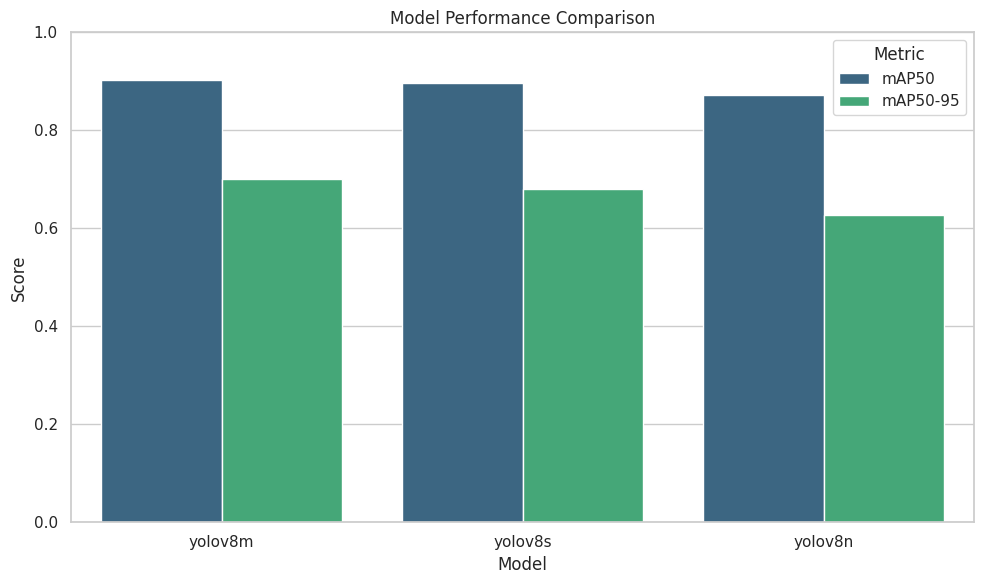

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ====== CONFIGURATION ======
# Must match the output directory from the Training Cell
PROJECT_DIR = "/content/yolo_ensemble"

print("="*70)
print("EVALUATING ENSEMBLE MODELS")
print("="*70)

metrics_list = []

# Iterate over the models defined in your global YOLO_MODELS config
for model_name in YOLO_MODELS.keys():
    # Construct path to the best weights
    # Structure from training: project_dir / name / weights / best.pt
    weights_path = os.path.join(PROJECT_DIR, model_name, "weights", "best.pt")

    if not os.path.exists(weights_path):
        print(f"⚠️ {model_name}: Weights not found at {weights_path} (Skipping)")
        continue

    print(f"\n🔍 Validating: {model_name}...")

    try:
        # Load model
        model = YOLO(weights_path)

        # Run validation
        # Using global DATA_YAML defined in 'Dataset & Training Config' cell
        val_results = model.val(data=DATA_YAML, split='val', verbose=False, plots=False)

        # Extract metrics
        metrics_list.append({
            "Model": model_name,
            "mAP50": val_results.box.map50,
            "mAP50-95": val_results.box.map,
            "Precision": val_results.box.mp,
            "Recall": val_results.box.mr
        })
        print(f"   ✅ mAP50: {val_results.box.map50:.4f}")

    except Exception as e:
        print(f"   ❌ Error validating {model_name}: {e}")

# Process and Display Results
if metrics_list:
    print("\n" + "="*70)
    print("🏆 FINAL PERFORMANCE LEADERBOARD")
    print("="*70)

    # Create DataFrame
    df_results = pd.DataFrame(metrics_list)
    df_results = df_results.sort_values(by="mAP50", ascending=False)

    # Display Table
    print(df_results.to_markdown(index=False, floatfmt=".4f"))

    # Save to CSV
    csv_path = os.path.join(PROJECT_DIR, "ensemble_metrics.csv")
    df_results.to_csv(csv_path, index=False)
    print(f"\n✅ Metrics saved to: {csv_path}")

    # Visualization
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")

    # Reshape for seaborn (Melt)
    df_melted = df_results.melt(id_vars="Model", value_vars=["mAP50", "mAP50-95"], var_name="Metric", value_name="Score")

    # Bar Plot
    sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric", palette="viridis")
    plt.title("Model Performance Comparison")
    plt.ylim(0, 1.0)
    plt.ylabel("Score")
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ No trained models found to evaluate.")

## 10. Load Best Models

In [15]:
!ls /content/drive/MyDrive/yolo_ensemble_project

In [16]:
!pip install -U ultralytics


In [17]:
from ultralytics import YOLO
print("Ultralytics imported successfully ✅")


Ultralytics imported successfully ✅


In [18]:
# ============================================
# Load Trained Models for Inference
# ============================================
from ultralytics import YOLO
import os

# Project directory for trained models
PROJECT_DIR = "/content/yolo_ensemble"

# Check if models were trained, otherwise use paths
models_paths = {}

# Try to find trained models
for model_name in ["yolov8n", "yolov8s", "yolov8m"]:
    # Check common training output paths
    possible_paths = [
        f"{PROJECT_DIR}/{model_name}/weights/best.pt",
        f"{PROJECT_DIR}/{model_name}2/weights/best.pt",
        f"{PROJECT_DIR}/{model_name}_retrained/weights/best.pt",
    ]

    found = False
    for path in possible_paths:
        if os.path.exists(path):
            models_paths[model_name] = path
            print(f"✅ Found {model_name}: {path}")
            found = True
            break

    if not found:
        # Use pretrained weights (will need training)
        models_paths[model_name] = f"{model_name}.pt"
        print(f"⚠️ {model_name}: Using pretrained weights (not trained yet)")

# Load models
models = []
for name, path in models_paths.items():
    try:
        model = YOLO(path)
        models.append(model)
        print(f"✅ Loaded {name}")
    except Exception as e:
        print(f"❌ Failed to load {name}: {e}")

print(f"\nTotal models loaded: {len(models)}")

✅ Found yolov8n: /content/yolo_ensemble/yolov8n/weights/best.pt
✅ Found yolov8s: /content/yolo_ensemble/yolov8s/weights/best.pt
✅ Found yolov8m: /content/yolo_ensemble/yolov8m/weights/best.pt
✅ Loaded yolov8n
✅ Loaded yolov8s
✅ Loaded yolov8m

Total models loaded: 3


In [19]:
# ============================================
# Model Comparison Table
# ============================================
import pandas as pd
from ultralytics import YOLO
import os

print("Evaluating all models on validation set...")

PROJECT_DIR = "/content/yolo_ensemble"

# Find trained models
models_to_eval = {}
for model_name in ["yolov8n", "yolov8s", "yolov8m"]:
    possible_paths = [
        f"{PROJECT_DIR}/{model_name}/weights/best.pt",
        f"{PROJECT_DIR}/{model_name}2/weights/best.pt",
        f"{PROJECT_DIR}/{model_name}_retrained/weights/best.pt",
    ]

    for path in possible_paths:
        if os.path.exists(path):
            models_to_eval[model_name.upper()] = path
            break

if len(models_to_eval) == 0:
    print("⚠️ No trained models found! Please run training first.")
else:
    results_table = []

    for name, path in models_to_eval.items():
        try:
            model = YOLO(path)
            metrics = model.val(data=DATA_YAML, verbose=False)

            results_table.append({
                "Model": name,
                "mAP@0.5": round(metrics.box.map50, 4),
                "mAP@0.5:0.95": round(metrics.box.map, 4),
                "Precision": round(metrics.box.mp, 4),
                "Recall": round(metrics.box.mr, 4),
            })
            print(f"✅ {name}: mAP50={metrics.box.map50:.4f}")
        except Exception as e:
            print(f"❌ {name}: Error - {e}")
            results_table.append({
                "Model": name,
                "mAP@0.5": "ERROR",
                "mAP@0.5:0.95": "ERROR",
                "Precision": "ERROR",
                "Recall": "ERROR",
            })

    # Create comparison DataFrame
    comparison = pd.DataFrame(results_table)

    print("\n" + "="*60)
    print("MODEL COMPARISON")
    print("="*60)
    print(comparison.to_string(index=False))
    print("="*60)

    # Highlight issues
    print("\n⚠️ NOTES:")
    for row in results_table:
        if isinstance(row["mAP@0.5"], float) and row["mAP@0.5"] < 0.5:
            print(f"  - {row['Model']} has low mAP ({row['mAP@0.5']}) - consider retraining!")

    comparison

Evaluating all models on validation set...
Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2830.4±692.3 MB/s, size: 146.7 KB)
val: Scanning /content/yolo_dataset/valid/labels.cache... 600 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 600/600 179.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 4.7it/s 8.1s
                   all        600       2097      0.831      0.816      0.873      0.626
Speed: 1.8ms preprocess, 3.7ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/detect/val4
✅ YOLOV8N: mAP50=0.8729
Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, r

In [20]:
!find /content/drive/MyDrive -name best.pt


/content/drive/MyDrive/yolo_ensemble_trained/yolov8m/weights/best.pt
/content/drive/MyDrive/yolo_ensemble_trained/yolov8n/weights/best.pt
/content/drive/MyDrive/yolo_ensemble_trained/yolov8s/weights/best.pt


In [21]:
from ultralytics import YOLO

models_paths = {
    "yolov8n": "/content/drive/MyDrive/yolo_ensemble_trained/yolov8n/weights/best.pt",
    "yolov8s": "/content/drive/MyDrive/yolo_ensemble_trained/yolov8s/weights/best.pt",
    "yolov8m": "/content/drive/MyDrive/yolo_ensemble_trained/yolov8m/weights/best.pt",
}

models = {name: YOLO(path) for name, path in models_paths.items()}


In [22]:
SOURCE = "/content/drive/MyDrive/yolo_dataset/test/images"

results = {}
for name, model in models.items():
    results[name] = model.predict(
        source=SOURCE,
        conf=0.25,
        iou=0.5,
        save=False,
        verbose=False
    )


In [23]:
path_n = "/content/drive/MyDrive/yolo_ensemble_trained/yolov8n/weights/best.pt"
path_s = "/content/drive/MyDrive/yolo_ensemble_trained/yolov8s/weights/best.pt"
path_m = "/content/drive/MyDrive/yolo_ensemble_trained/yolov8m/weights/best.pt"

TEST_DIR = "/content/drive/MyDrive/yolo_dataset/test/images"


In [24]:
from ultralytics import YOLO

results = {}

results["yolov8n"] = YOLO(path_n).predict(source=TEST_DIR, conf=0.25)
results["yolov8s"] = YOLO(path_s).predict(source=TEST_DIR, conf=0.25)
results["yolov8m"] = YOLO(path_m).predict(source=TEST_DIR, conf=0.25)



image 1/303 /content/drive/MyDrive/yolo_dataset/test/images/fshoplifting_2_11_192_jpg.rf.7975c5eb852643acc0f8cecd40cc925e.jpg: 640x640 1 Customer-Bagpack, 1 normal, 1 theft, 7.5ms
image 2/303 /content/drive/MyDrive/yolo_dataset/test/images/fshoplifting_2_11_606_jpg.rf.59d501d30b9eaf8a85ab45d0c3ccf8c5.jpg: 640x640 2 Customer-Bagpacks, 1 Product-Picked, 2 normals, 1 theft, 7.2ms
image 3/303 /content/drive/MyDrive/yolo_dataset/test/images/fshoplifting_2_11_660_jpg.rf.40e72a94b42da9810fcf144bea02a798.jpg: 640x640 1 Customer-Bagpack, 2 normals, 1 theft, 7.2ms
image 4/303 /content/drive/MyDrive/yolo_dataset/test/images/fshoplifting_2_11_702_jpg.rf.8f7b2c101911b1618211b6326b86d9d6.jpg: 640x640 2 Customer-Bagpacks, 3 normals, 7.2ms
image 5/303 /content/drive/MyDrive/yolo_dataset/test/images/fshoplifting_2_11_738_jpg.rf.4389b1d220ee7ea87c884c3a08b9d338.jpg: 640x640 3 Customer-Bagpacks, 1 normal, 1 theft, 7.2ms
image 6/303 /content/drive/MyDrive/yolo_dataset/test/images/fshoplifting_2_11_744_jp

In [25]:
import torch
from torchvision.ops import nms


In [26]:
import torch
from torchvision.ops import nms
import numpy as np

def ensemble_boxes_single_image(model_results_for_image, iou_thr=0.5, conf_thr=0.25):
    """
    FIXED: Ensemble boxes for a SINGLE image from multiple models.

    Args:
        model_results_for_image: List of prediction results from each model for ONE image
        iou_thr: IoU threshold for NMS
        conf_thr: Confidence threshold

    Returns:
        boxes, scores, labels for the fused detections
    """
    boxes_all, scores_all, labels_all = [], [], []

    for res in model_results_for_image:
        if res is None or res.boxes is None or len(res.boxes) == 0:
            continue

        boxes = res.boxes.xyxy.cpu()
        scores = res.boxes.conf.cpu()
        labels = res.boxes.cls.cpu()

        # Filter by confidence
        keep = scores > conf_thr
        if keep.sum() == 0:
            continue

        boxes_all.append(boxes[keep])
        scores_all.append(scores[keep])
        labels_all.append(labels[keep])

    if len(boxes_all) == 0:
        return torch.empty((0, 4)), torch.empty(0), torch.empty(0)

    boxes = torch.cat(boxes_all)
    scores = torch.cat(scores_all)
    labels = torch.cat(labels_all)

    # Apply NMS
    keep = nms(boxes, scores, iou_thr)

    return boxes[keep], scores[keep], labels[keep]


def ensemble_predict_all_images(results_dict, iou_thr=0.5, conf_thr=0.25):
    """
    FIXED: Run ensemble on ALL images, processing each image separately.

    Args:
        results_dict: Dict of {model_name: [results_per_image]}
        iou_thr: IoU threshold for NMS
        conf_thr: Confidence threshold

    Returns:
        Dict of {image_path: (boxes, scores, labels)}
    """
    model_names = list(results_dict.keys())
    num_images = len(results_dict[model_names[0]])

    ensemble_results = {}

    for img_idx in range(num_images):
        # Get results from all models for this specific image
        model_results_for_image = []
        img_path = None

        for model_name in model_names:
            res = results_dict[model_name][img_idx]
            model_results_for_image.append(res)
            if img_path is None:
                img_path = res.path

        # Ensemble for this single image
        boxes, scores, labels = ensemble_boxes_single_image(
            model_results_for_image,
            iou_thr=iou_thr,
            conf_thr=conf_thr
        )

        ensemble_results[img_path] = {
            'boxes': boxes,
            'scores': scores,
            'labels': labels
        }

    return ensemble_results

print("✅ Fixed ensemble functions loaded")

✅ Fixed ensemble functions loaded


In [27]:
img_index = 0  # أول صورة بس (عشان نفهم)

all_results = [
    results["yolov8n"][img_index],
    results["yolov8s"][img_index],
    results["yolov8m"][img_index],
]

# Corrected function call to use the defined ensemble_boxes_single_image function
final_boxes, final_scores, final_labels = ensemble_boxes_single_image(all_results, iou_thr=IOU_THRESHOLD, conf_thr=CONF_THRESHOLD)

print("Final detections:", len(final_boxes))

Final detections: 3


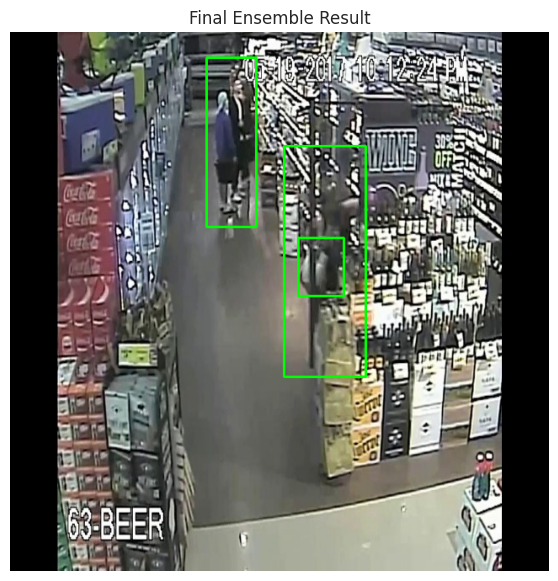

In [28]:
import cv2
import matplotlib.pyplot as plt

img_path = results["yolov8n"][img_index].path
img = cv2.imread(img_path)

for box in final_boxes:
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

plt.figure(figsize=(7,7))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Final Ensemble Result")
plt.axis("off")
plt.show()


In [29]:
for name, res in results.items():
    count = sum(len(r.boxes) for r in res if r.boxes is not None)
    print(name, "detections:", count)


yolov8n detections: 1019
yolov8s detections: 1002
yolov8m detections: 1008


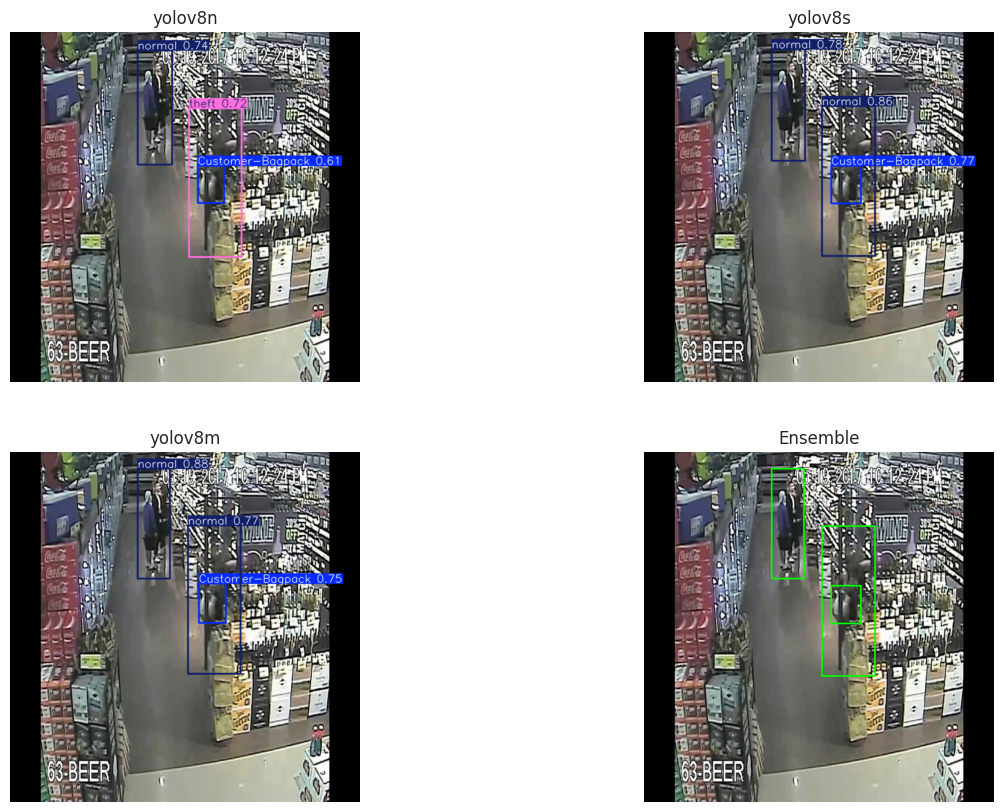

In [30]:
models = ["yolov8n", "yolov8s", "yolov8m"]

plt.figure(figsize=(15,10))

for i, model in enumerate(models):
    res = results[model][img_index]
    img = cv2.imread(res.path)
    annotated = res.plot()

    plt.subplot(2,2,i+1)
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(model)
    plt.axis("off")

# Ensemble
img = cv2.imread(results["yolov8n"][img_index].path)
for box in final_boxes:
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

plt.subplot(2,2,4)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Ensemble")
plt.axis("off")

plt.show()


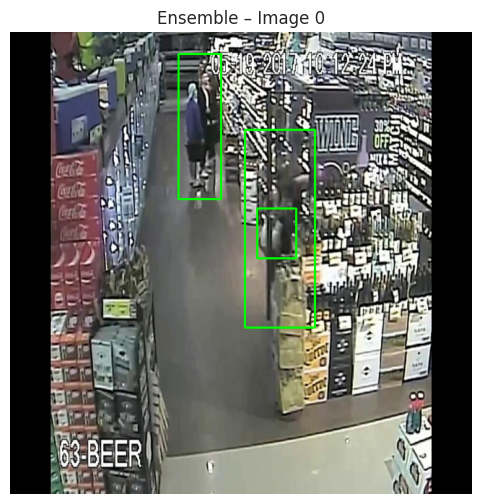

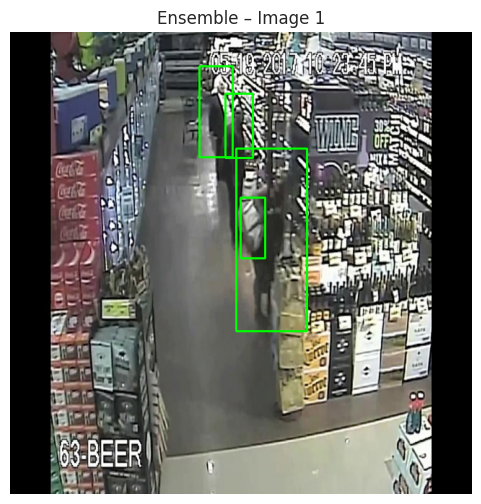

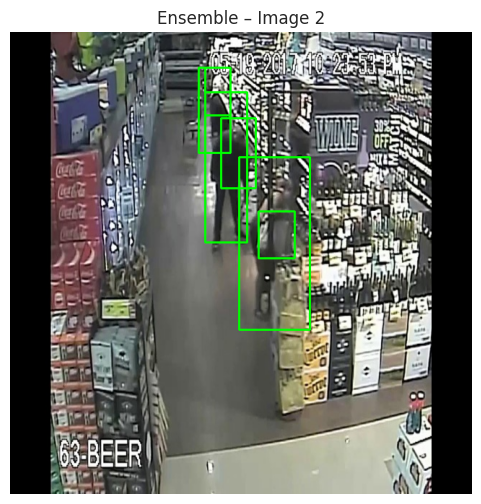

In [31]:
for img_index in range(3):  # غيري الرقم لو عايزة أكتر
    all_results = [
        results["yolov8n"][img_index],
        results["yolov8s"][img_index],
        results["yolov8m"][img_index],
    ]

    final_boxes, final_scores, final_labels = ensemble_boxes_single_image(all_results, iou_thr=IOU_THRESHOLD, conf_thr=CONF_THRESHOLD)

    img_path = results["yolov8n"][img_index].path
    img = cv2.imread(img_path)

    for box in final_boxes:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Ensemble – Image {img_index}")
    plt.axis("off")
    plt.show()

In [32]:
print(locals().keys())


dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', 'drive', '_i2', 'os', 'shutil', 'yaml', 'DRIVE_DATASET_PATH', 'DATASET_PATH', 'possible_paths', 'path', 'data_yaml_path', 'f', 'data_config', 'root', 'dirs', 'files', 'file', 'cache_path', '_exit_code', 'essential', 'item', '_i3', '_i4', '_i5', 'YOLO', 'torch', 'weighted_boxes_fusion', '_i6', '_i7', '_i8', 'DATA_YAML', 'EPOCHS', 'IMG_SIZE', 'BATCH', 'CONF_THRESHOLD', 'IOU_THRESHOLD', 'TEST_IMAGES_DIR', 'TEST_LABELS_DIR', 'VALID_IMAGES_DIR', 'VALID_LABELS_DIR', 'CLASS_NAMES', '_i9', '_i10', 'train_model', '_i11', 'datetime', 'platform', 'PROJECT_DIR', 'NUM_WORKERS', '_i12', 'YOLO_MODELS', '_i13', 'model_name', 'weights', 'final_weights_path', 'url', 'model', 'results', 'drive_backup', '_i14', 'pd', 'plt', 'sns', 'metrics_list', 'weights_path', 'val_results', 'df_results', '

In [33]:
import numpy as np

def extract_boxes(results):
    boxes = []
    scores = []
    labels = []

    for r in results:
        if r.boxes is None:
            continue

        boxes.append(r.boxes.xyxy.cpu().numpy())
        scores.append(r.boxes.conf.cpu().numpy())
        labels.append(r.boxes.cls.cpu().numpy())

    if len(boxes) == 0:
        return np.empty((0,4)), np.array([]), np.array([])

    return np.vstack(boxes), np.hstack(scores), np.hstack(labels)


In [34]:
from torchvision.ops import nms
import torch

def ensemble_nms(all_results, iou_thresh=0.5):
    all_boxes, all_scores, all_labels = [], [], []

    for res in all_results:
        b, s, l = extract_boxes(res)
        if len(b) == 0:
            continue
        all_boxes.append(b)
        all_scores.append(s)
        all_labels.append(l)

    boxes = torch.tensor(np.vstack(all_boxes), dtype=torch.float32)
    scores = torch.tensor(np.hstack(all_scores))
    labels = torch.tensor(np.hstack(all_labels))

    keep = nms(boxes, scores, iou_thresh)

    return boxes[keep], scores[keep], labels[keep]


In [35]:
all_results = [results[k] for k in results]

final_boxes, final_scores, final_labels = ensemble_nms(all_results)

print("Final Ensemble detections:", len(final_boxes))


Final Ensemble detections: 208


In [36]:
import yaml

with open(DATA_YAML, "r") as f:
    data = yaml.safe_load(f)

class_names = data["names"]


✅ WBF ensemble functions loaded
   Model weights: [1.0, 0.3, 1.0]
Running WBF Ensemble on test images...

Total images processed: 303
Total ensemble detections: 1092

Visualizing results...


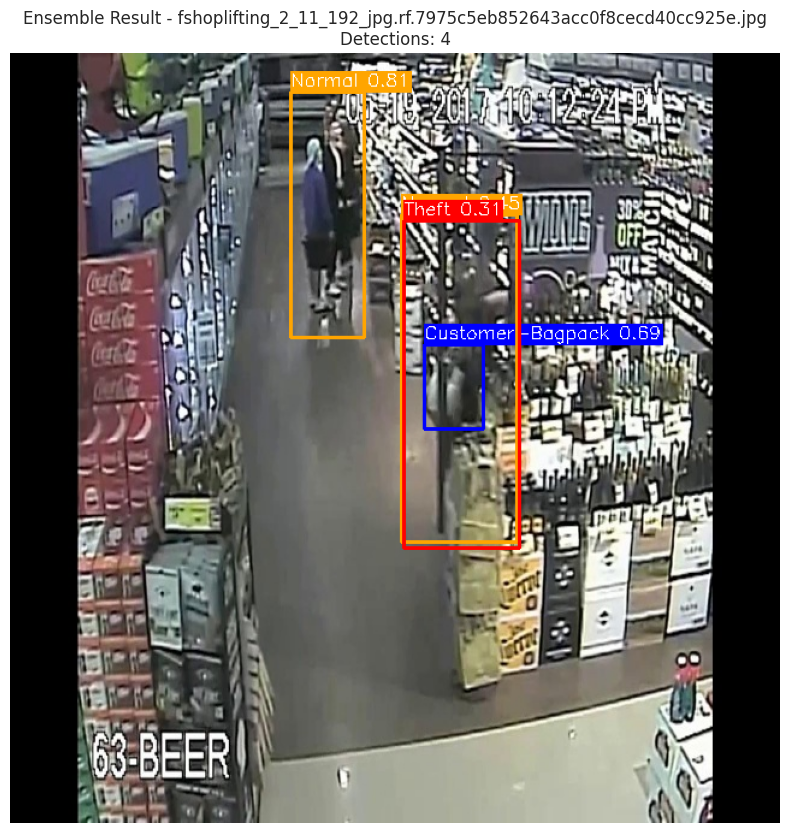

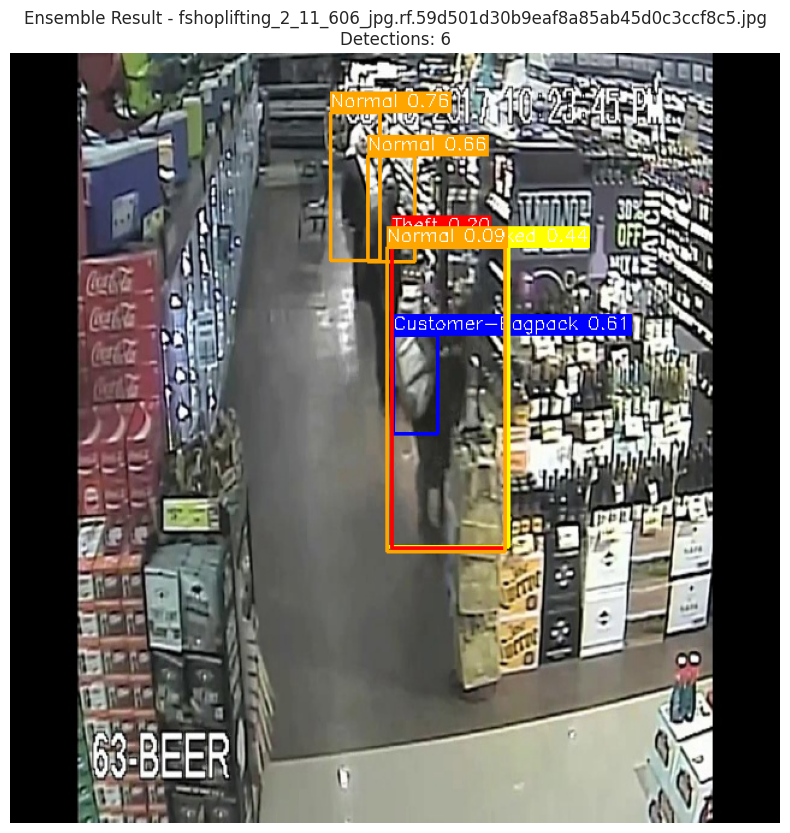

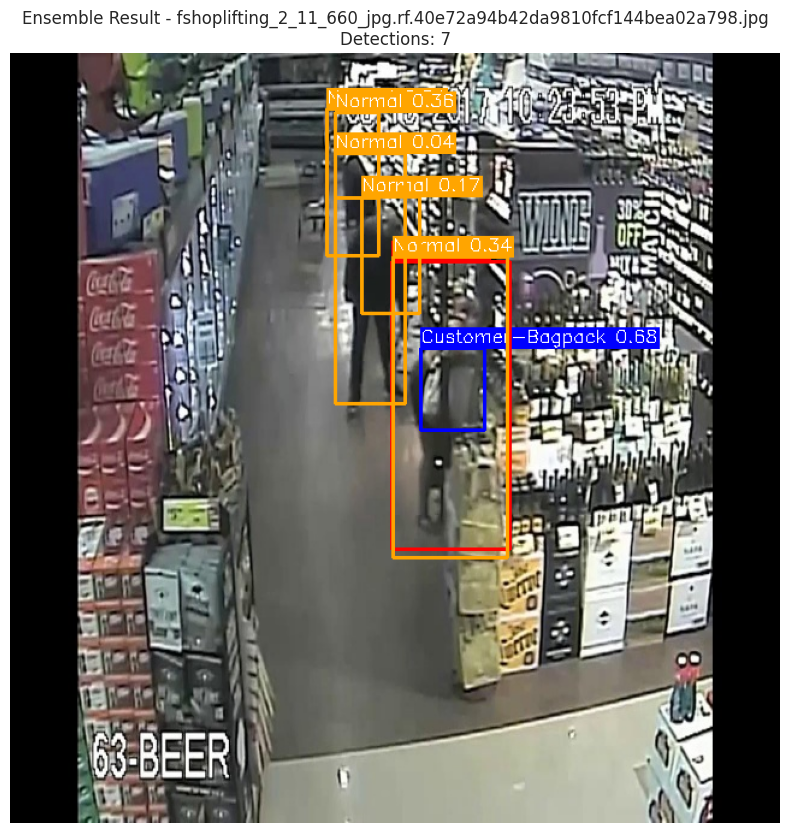

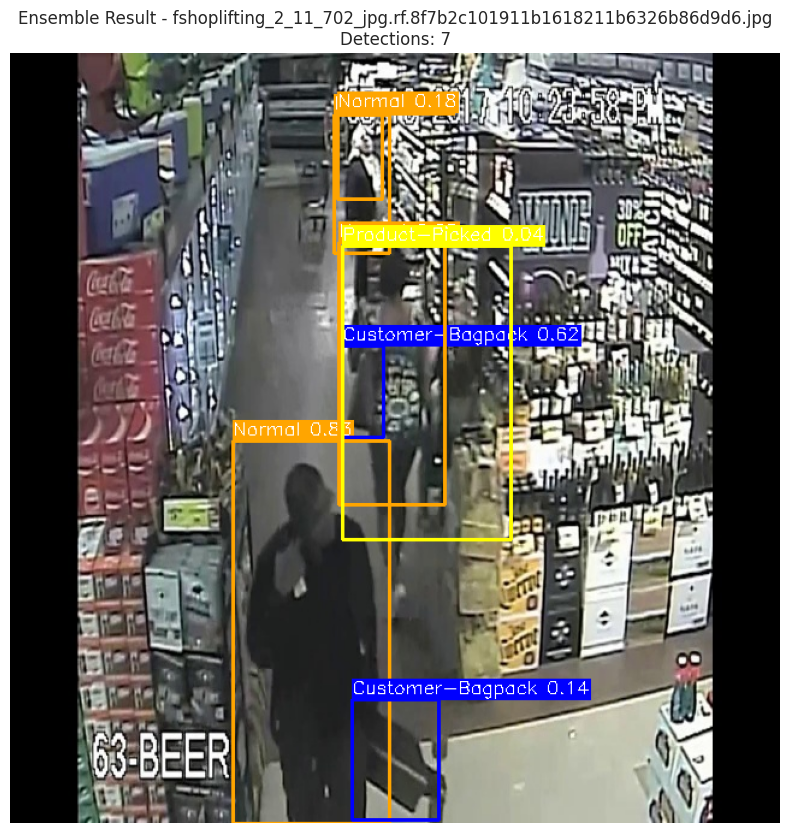

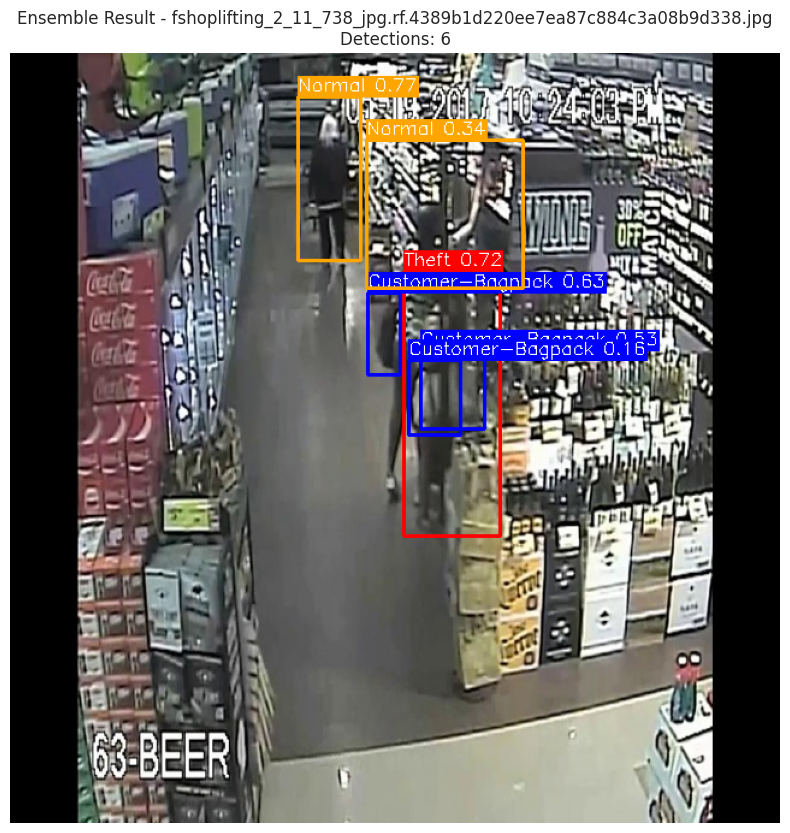

In [37]:
# ============================================
# FIXED: Visualization with Proper Per-Image Ensemble
# ============================================
import cv2
import matplotlib.pyplot as plt
import os

# ============================================
# IMPROVED: Weighted Boxes Fusion (WBF) Ensemble
# WBF is better than NMS for ensemble as it averages boxes
# ============================================
from ensemble_boxes import weighted_boxes_fusion
import numpy as np

def ensemble_wbf_single_image(model_results_for_image, img_width, img_height,
                               iou_thr=0.55, skip_box_thr=0.25, weights=None):
    """
    Apply Weighted Boxes Fusion for a single image.
    WBF averages the coordinates of boxes that overlap, giving better localization.

    Args:
        model_results_for_image: List of prediction results from each model
        img_width, img_height: Image dimensions for normalization
        iou_thr: IoU threshold for fusion
        skip_box_thr: Confidence threshold to skip boxes
        weights: Optional weights for each model (default: equal weights)

    Returns:
        boxes (xyxy), scores, labels
    """
    all_boxes = []
    all_scores = []
    all_labels = []

    for res in model_results_for_image:
        if res is None or res.boxes is None or len(res.boxes) == 0:
            all_boxes.append([])
            all_scores.append([])
            all_labels.append([])
            continue

        boxes = res.boxes.xyxy.cpu().numpy()
        scores = res.boxes.conf.cpu().numpy()
        labels = res.boxes.cls.cpu().numpy().astype(int)

        # Normalize boxes to [0, 1] range (required by WBF)
        norm_boxes = []
        for x1, y1, x2, y2 in boxes:
            norm_boxes.append([
                x1 / img_width,
                y1 / img_height,
                x2 / img_width,
                y2 / img_height
            ])

        all_boxes.append(norm_boxes)
        all_scores.append(scores.tolist())
        all_labels.append(labels.tolist())

    # Check if all empty
    if all(len(b) == 0 for b in all_boxes):
        return np.empty((0, 4)), np.array([]), np.array([])

    # Set default weights (equal)
    if weights is None:
        weights = [1.0] * len(all_boxes)

    # Apply WBF
    fused_boxes, fused_scores, fused_labels = weighted_boxes_fusion(
        all_boxes,
        all_scores,
        all_labels,
        weights=weights,
        iou_thr=iou_thr,
        skip_box_thr=skip_box_thr
    )

    # Convert back to pixel coordinates
    fused_boxes_pixel = np.array([
        [b[0] * img_width, b[1] * img_height, b[2] * img_width, b[3] * img_height]
        for b in fused_boxes
    ]) if len(fused_boxes) > 0 else np.empty((0, 4))

    return fused_boxes_pixel, fused_scores, fused_labels.astype(int)


def ensemble_wbf_all_images(results_dict, iou_thr=0.55, skip_box_thr=0.25, weights=None):
    """
    Apply WBF ensemble to all images.

    Args:
        results_dict: Dict of {model_name: [results_per_image]}
        iou_thr: IoU threshold for WBF
        skip_box_thr: Skip boxes with confidence below this
        weights: Optional model weights (e.g., [1.0, 0.5, 1.0] to downweight bad model)

    Returns:
        Dict of {image_path: {'boxes': ..., 'scores': ..., 'labels': ...}}
    """
    model_names = list(results_dict.keys())
    num_images = len(results_dict[model_names[0]])

    ensemble_results = {}

    for img_idx in range(num_images):
        # Get results from all models for this image
        model_results = []
        img_path = None
        img_shape = None

        for model_name in model_names:
            res = results_dict[model_name][img_idx]
            model_results.append(res)
            if img_path is None:
                img_path = res.path
                # Get image dimensions
                img = cv2.imread(img_path)
                if img is not None:
                    img_shape = img.shape[:2]  # (height, width)

        if img_shape is None:
            continue

        h, w = img_shape

        # Apply WBF for this image
        boxes, scores, labels = ensemble_wbf_single_image(
            model_results,
            img_width=w,
            img_height=h,
            iou_thr=iou_thr,
            skip_box_thr=skip_box_thr,
            weights=weights
        )

        ensemble_results[img_path] = {
            'boxes': boxes,
            'scores': scores,
            'labels': labels
        }

    return ensemble_results


# Example: Downweight YOLOv8s since it performed poorly
# YOLOv8n: good (1.0), YOLOv8s: bad (0.3), YOLOv8m: good (1.0)
MODEL_WEIGHTS = [1.0, 0.3, 1.0]  # Adjust based on individual model performance

print("✅ WBF ensemble functions loaded")
print(f"   Model weights: {MODEL_WEIGHTS}")

# Color map for classes
COLORS = {
    0: (255, 0, 0),      # Customer-Bagpack - Blue
    1: (0, 255, 0),      # Product - Green
    2: (0, 255, 255),    # Product-Picked - Yellow
    3: (255, 0, 255),    # Shopping-Cart - Magenta
    4: (0, 165, 255),    # Normal - Orange
    5: (0, 0, 255),      # Theft - Red
}

def visualize_ensemble_results(ensemble_results, num_images=5, save_dir=None):
    """
    Visualize ensemble predictions on images.

    Args:
        ensemble_results: Dict from ensemble_wbf_all_images or ensemble_predict_all_images
        num_images: Number of images to visualize
        save_dir: Optional directory to save visualizations
    """
    img_paths = list(ensemble_results.keys())[:num_images]

    for img_path in img_paths:
        result = ensemble_results[img_path]

        img = cv2.imread(img_path)
        if img is None:
            print(f"Could not read: {img_path}")
            continue

        boxes = result['boxes']
        scores = result['scores']
        labels = result['labels']

        # Draw each detection
        for box, score, label in zip(boxes, scores, labels):
            x1, y1, x2, y2 = map(int, box)
            cls_idx = int(label)
            cls_name = CLASS_NAMES[cls_idx] if cls_idx < len(CLASS_NAMES) else f"Class_{cls_idx}"
            conf = float(score)

            color = COLORS.get(cls_idx, (255, 255, 255))

            # Draw box
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

            # Draw label background
            label_text = f"{cls_name} {conf:.2f}"
            (text_w, text_h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(img, (x1, y1 - text_h - 5), (x1 + text_w, y1), color, -1)

            # Draw label text
            cv2.putText(img, label_text, (x1, y1 - 5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        # Display
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 10))
        plt.imshow(img_rgb)
        plt.title(f"Ensemble Result - {os.path.basename(img_path)}\nDetections: {len(boxes)}")
        plt.axis("off")

        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
            save_path = os.path.join(save_dir, f"ensemble_{os.path.basename(img_path)}")
            plt.savefig(save_path, bbox_inches='tight', dpi=150)
            print(f"Saved: {save_path}")

        plt.show()


# Run WBF ensemble (better than NMS)
print("Running WBF Ensemble on test images...")
ensemble_results_wbf = ensemble_wbf_all_images(
    results,
    iou_thr=0.55,
    skip_box_thr=CONF_THRESHOLD,
    weights=MODEL_WEIGHTS  # Downweight broken YOLOv8s
)

print(f"\nTotal images processed: {len(ensemble_results_wbf)}")

# Count total detections
total_detections = sum(len(r['boxes']) for r in ensemble_results_wbf.values())
print(f"Total ensemble detections: {total_detections}")

# Visualize first 5 images
print("\nVisualizing results...")
visualize_ensemble_results(ensemble_results_wbf, num_images=5)

In [38]:
# ============================================
# IMPROVED: Weighted Boxes Fusion (WBF) Ensemble
# WBF is better than NMS for ensemble as it averages boxes
# ============================================
from ensemble_boxes import weighted_boxes_fusion
import numpy as np

def ensemble_wbf_single_image(model_results_for_image, img_width, img_height,
                               iou_thr=0.55, skip_box_thr=0.25, weights=None):
    """
    Apply Weighted Boxes Fusion for a single image.
    WBF averages the coordinates of boxes that overlap, giving better localization.

    Args:
        model_results_for_image: List of prediction results from each model
        img_width, img_height: Image dimensions for normalization
        iou_thr: IoU threshold for fusion
        skip_box_thr: Confidence threshold to skip boxes
        weights: Optional weights for each model (default: equal weights)

    Returns:
        boxes (xyxy), scores, labels
    """
    all_boxes = []
    all_scores = []
    all_labels = []

    for res in model_results_for_image:
        if res is None or res.boxes is None or len(res.boxes) == 0:
            all_boxes.append([])
            all_scores.append([])
            all_labels.append([])
            continue

        boxes = res.boxes.xyxy.cpu().numpy()
        scores = res.boxes.conf.cpu().numpy()
        labels = res.boxes.cls.cpu().numpy().astype(int)

        # Normalize boxes to [0, 1] range (required by WBF)
        norm_boxes = []
        for x1, y1, x2, y2 in boxes:
            norm_boxes.append([
                x1 / img_width,
                y1 / img_height,
                x2 / img_width,
                y2 / img_height
            ])

        all_boxes.append(norm_boxes)
        all_scores.append(scores.tolist())
        all_labels.append(labels.tolist())

    # Check if all empty
    if all(len(b) == 0 for b in all_boxes):
        return np.empty((0, 4)), np.array([]), np.array([])

    # Set default weights (equal)
    if weights is None:
        weights = [1.0] * len(all_boxes)

    # Apply WBF
    fused_boxes, fused_scores, fused_labels = weighted_boxes_fusion(
        all_boxes,
        all_scores,
        all_labels,
        weights=weights,
        iou_thr=iou_thr,
        skip_box_thr=skip_box_thr
    )

    # Convert back to pixel coordinates
    fused_boxes_pixel = np.array([
        [b[0] * img_width, b[1] * img_height, b[2] * img_width, b[3] * img_height]
        for b in fused_boxes
    ]) if len(fused_boxes) > 0 else np.empty((0, 4))

    return fused_boxes_pixel, fused_scores, fused_labels.astype(int)


def ensemble_wbf_all_images(results_dict, iou_thr=0.55, skip_box_thr=0.25, weights=None):
    """
    Apply WBF ensemble to all images.

    Args:
        results_dict: Dict of {model_name: [results_per_image]}
        iou_thr: IoU threshold for WBF
        skip_box_thr: Skip boxes with confidence below this
        weights: Optional model weights (e.g., [1.0, 0.5, 1.0] to downweight bad model)

    Returns:
        Dict of {image_path: {'boxes': ..., 'scores': ..., 'labels': ...}}
    """
    model_names = list(results_dict.keys())
    num_images = len(results_dict[model_names[0]])

    ensemble_results = {}

    for img_idx in range(num_images):
        # Get results from all models for this image
        model_results = []
        img_path = None
        img_shape = None

        for model_name in model_names:
            res = results_dict[model_name][img_idx]
            model_results.append(res)
            if img_path is None:
                img_path = res.path
                # Get image dimensions
                img = cv2.imread(img_path)
                if img is not None:
                    img_shape = img.shape[:2]  # (height, width)

        if img_shape is None:
            continue

        h, w = img_shape

        # Apply WBF for this image
        boxes, scores, labels = ensemble_wbf_single_image(
            model_results,
            img_width=w,
            img_height=h,
            iou_thr=iou_thr,
            skip_box_thr=skip_box_thr,
            weights=weights
        )

        ensemble_results[img_path] = {
            'boxes': boxes,
            'scores': scores,
            'labels': labels
        }

    return ensemble_results


# Example: Downweight YOLOv8s since it performed poorly
# YOLOv8n: good (1.0), YOLOv8s: bad (0.3), YOLOv8m: good (1.0)
MODEL_WEIGHTS = [1.0, 0.3, 1.0]  # Adjust based on individual model performance

print("✅ WBF ensemble functions loaded")
print(f"   Model weights: {MODEL_WEIGHTS}")

✅ WBF ensemble functions loaded
   Model weights: [1.0, 0.3, 1.0]


In [ ]:
# /////////////////////////////

In [39]:
# ============================================
# RETRAIN YOLOv8s - It was broken/undertrained
# ============================================
print("="*60)
print("RETRAINING YOLOv8s (was broken with mAP=0.039)")
print("="*60)

from ultralytics import YOLO

# Fresh start with pretrained weights
model_s = YOLO("yolov8s.pt")

# Train with optimized parameters
results_s = model_s.train(
    data=DATA_YAML,
    epochs=100,              # More epochs for better convergence
    batch=BATCH,
    imgsz=IMG_SIZE,
    device=0,

    # Optimized learning rate
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    cos_lr=True,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=5,         # Longer warmup

    # Class imbalance handling
    cls=1.5,
    box=7.5,

    # Augmentations
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.15,
    copy_paste=0.1,

    # Training settings
    patience=20,             # Early stopping
    amp=True,
    cache=True,              # Cache images for faster training

    project="yolo_ensemble",
    name="yolov8s_retrained",
    pretrained=True,
    verbose=True,
    plots=True,
    save=True,
    seed=42,
    val=True,
    exist_ok=True
)

print(f"\n✅ YOLOv8s RETRAINED")
print(f"Saved to: {results_s.save_dir}")

# Validate the retrained model
print("\nValidating retrained YOLOv8s...")
model_s_new = YOLO(f"{results_s.save_dir}/weights/best.pt")
metrics = model_s_new.val(data=DATA_YAML)

print(f"\nRetrained YOLOv8s Results:")
print(f"  mAP50:    {metrics.box.map50:.4f}")
print(f"  mAP50-95: {metrics.box.map:.4f}")

RETRAINING YOLOv8s (was broken with mAP=0.039)
Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=1.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_retrained, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, o

In [42]:
from ultralytics import YOLO

# paths
path_n = "/content/drive/MyDrive/yolo_ensemble_project/yolov8n/weights/best.pt"
path_s = "/content/drive/MyDrive/yolo_ensemble_project/yolov8s/weights/best.pt"
path_m = "/content/drive/MyDrive/yolo_ensemble_project/yolov8m/weights/best.pt"

TEST_DIR = "/content/drive/MyDrive/yolo_dataset/test/images"

# ensemble inference
results = {}
results["yolov8n"] = YOLO(path_n).predict(source=TEST_DIR, conf=0.25, iou=0.5, save=False)
results["yolov8s"] = YOLO(path_s).predict(source=TEST_DIR, conf=0.25, iou=0.5, save=False)
results["yolov8m"] = YOLO(path_m).predict(source=TEST_DIR, conf=0.25, iou=0.5, save=False)

print("Ensemble models loaded:", results.keys())



image 1/303 /content/drive/MyDrive/yolo_dataset/test/images/fshoplifting_2_11_192_jpg.rf.7975c5eb852643acc0f8cecd40cc925e.jpg: 640x640 1 Customer-Bagpack, 1 normal, 1 theft, 7.4ms
image 2/303 /content/drive/MyDrive/yolo_dataset/test/images/fshoplifting_2_11_606_jpg.rf.59d501d30b9eaf8a85ab45d0c3ccf8c5.jpg: 640x640 2 Customer-Bagpacks, 1 Product-Picked, 2 normals, 1 theft, 9.7ms
image 3/303 /content/drive/MyDrive/yolo_dataset/test/images/fshoplifting_2_11_660_jpg.rf.40e72a94b42da9810fcf144bea02a798.jpg: 640x640 1 Customer-Bagpack, 2 normals, 1 theft, 7.7ms
image 4/303 /content/drive/MyDrive/yolo_dataset/test/images/fshoplifting_2_11_702_jpg.rf.8f7b2c101911b1618211b6326b86d9d6.jpg: 640x640 2 Customer-Bagpacks, 3 normals, 22.6ms
image 5/303 /content/drive/MyDrive/yolo_dataset/test/images/fshoplifting_2_11_738_jpg.rf.4389b1d220ee7ea87c884c3a08b9d338.jpg: 640x640 3 Customer-Bagpacks, 1 normal, 1 theft, 7.3ms
image 6/303 /content/drive/MyDrive/yolo_dataset/test/images/fshoplifting_2_11_744_j

In [43]:
!pip install ultralytics


In [44]:
from ultralytics import YOLO
print("YOLO ready ✅")


YOLO ready ✅


In [45]:
!pip install ultralytics


In [46]:
from ultralytics import YOLO
import os
import cv2
import numpy as np
print("Environment ready ✅")


Environment ready ✅


In [47]:
path_n = "/content/drive/MyDrive/yolo_ensemble_project/yolov8n/weights/best.pt"
path_s = "/content/drive/MyDrive/yolo_ensemble_project/yolov8s/weights/best.pt"
path_m = "/content/drive/MyDrive/yolo_ensemble_project/yolov8m/weights/best.pt"

TEST_DIR = "/content/drive/MyDrive/yolo_dataset/test/images"

results = {}
results["yolov8n"] = YOLO(path_n).predict(source=TEST_DIR, conf=0.5, iou=0.5, save=False)
results["yolov8s"] = YOLO(path_s).predict(source=TEST_DIR, conf=0.5, iou=0.5, save=False)
results["yolov8m"] = YOLO(path_m).predict(source=TEST_DIR, conf=0.5, iou=0.5, save=False)

print("Ensemble models loaded:", results.keys())



image 1/303 /content/drive/MyDrive/yolo_dataset/test/images/fshoplifting_2_11_192_jpg.rf.7975c5eb852643acc0f8cecd40cc925e.jpg: 640x640 1 Customer-Bagpack, 1 normal, 1 theft, 8.7ms
image 2/303 /content/drive/MyDrive/yolo_dataset/test/images/fshoplifting_2_11_606_jpg.rf.59d501d30b9eaf8a85ab45d0c3ccf8c5.jpg: 640x640 1 Customer-Bagpack, 1 normal, 7.3ms
image 3/303 /content/drive/MyDrive/yolo_dataset/test/images/fshoplifting_2_11_660_jpg.rf.40e72a94b42da9810fcf144bea02a798.jpg: 640x640 1 Customer-Bagpack, 1 normal, 1 theft, 7.3ms
image 4/303 /content/drive/MyDrive/yolo_dataset/test/images/fshoplifting_2_11_702_jpg.rf.8f7b2c101911b1618211b6326b86d9d6.jpg: 640x640 1 Customer-Bagpack, 2 normals, 17.8ms
image 5/303 /content/drive/MyDrive/yolo_dataset/test/images/fshoplifting_2_11_738_jpg.rf.4389b1d220ee7ea87c884c3a08b9d338.jpg: 640x640 1 Customer-Bagpack, 1 normal, 1 theft, 7.5ms
image 6/303 /content/drive/MyDrive/yolo_dataset/test/images/fshoplifting_2_11_744_jpg.rf.6d33e2293d913bd1f77ebc6bb5

In [48]:
ensemble_detections = []

for model_name, model_results in results.items():
    for r in model_results:
        if r.boxes is None:
            continue

        for box in r.boxes:
            cls = int(box.cls[0])
            conf = float(box.conf[0])
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

            # فلترة بسيطة تقلل FP
            if conf < 0.25:
                continue

            ensemble_detections.append([
                cls, x1, y1, x2, y2, conf
            ])

print("Total ensemble detections:", len(ensemble_detections))
print("Sample detection:", ensemble_detections[0])


Total ensemble detections: 2711
Sample detection: [4, np.float32(233.13751), np.float32(33.827866), np.float32(296.2472), np.float32(242.50829), 0.7400670051574707]


In [49]:
# ============================================
# FIXED: Proper Per-Image Evaluation (Moved from JIYo0DHsBpcT)
# ============================================
import os
import numpy as np
import cv2 # Ensure cv2 is imported for image operations
import torch # Ensure torch is imported for tensor operations

# Use paths from global config
LABELS_DIR = TEST_LABELS_DIR
IMAGES_DIR = TEST_IMAGES_DIR

def calculate_iou(box1, box2):
    """Calculate IoU between two boxes [x1, y1, x2, y2]"""
    xa = max(box1[0], box2[0])
    ya = max(box1[1], box2[1])
    xb = min(box1[2], box2[2])
    yb = min(box1[3], box2[3])

    inter = max(0, xb - xa) * max(0, yb - ya)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    return inter / (area1 + area2 - inter + 1e-6)


def load_ground_truth(label_path, img_width, img_height):
    """Load YOLO format labels and convert to xyxy format"""
    gt_boxes = []

    if not os.path.exists(label_path):
        return gt_boxes

    with open(label_path, "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls, xc, yc, bw, bh = map(float, parts[:5])

            # Convert YOLO format (center, width, height) to xyxy
            x1 = int((xc - bw/2) * img_width)
            y1 = int((yc - bh/2) * img_height)
            x2 = int((xc + bw/2) * img_width)
            y2 = int((yc + bh/2) * img_height)

            gt_boxes.append({
                'cls': int(cls),
                'box': [x1, y1, x2, y2]
            })

    return gt_boxes


def evaluate_ensemble_properly(ensemble_results, labels_dir, images_dir, iou_thresh=0.5):
    """
    FIXED: Properly evaluate ensemble results against ground truth.
    Processes each image separately and aggregates metrics.
    """
    total_TP = 0
    total_FP = 0
    total_FN = 0

    # Per-class metrics
    class_metrics = {i: {'TP': 0, 'FP': 0, 'FN': 0} for i in range(len(CLASS_NAMES))}

    for img_path, result in ensemble_results.items():
        # Get image dimensions
        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]

        # Get corresponding label file
        img_name = os.path.basename(img_path)
        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(labels_dir, label_name)

        # Load ground truth for THIS image
        gt_boxes = load_ground_truth(label_path, w, h)

        # Get predictions for THIS image
        pred_boxes = result['boxes']
        pred_scores = result['scores']
        pred_labels = result['labels']

        # Match predictions to ground truth
        matched_gt = set()

        for i, (pred_box, pred_score, pred_label) in enumerate(zip(pred_boxes, pred_scores, pred_labels)):
            pred_box = pred_box.numpy() if torch.is_tensor(pred_box) else pred_box
            pred_cls = int(pred_label.item() if torch.is_tensor(pred_label) else pred_label)

            matched = False
            for gt_idx, gt in enumerate(gt_boxes):
                if gt_idx in matched_gt:
                    continue

                # Check class match and IoU
                if pred_cls == gt['cls']:
                    iou = calculate_iou(pred_box, gt['box'])
                    if iou >= iou_thresh:
                        total_TP += 1
                        class_metrics[pred_cls]['TP'] += 1
                        matched_gt.add(gt_idx)
                        matched = True
                        break

            if not matched:
                total_FP += 1
                if pred_cls < len(CLASS_NAMES):
                    class_metrics[pred_cls]['FP'] += 1

        # Count unmatched ground truth as FN
        for gt_idx, gt in enumerate(gt_boxes):
            if gt_idx not in matched_gt:
                total_FN += 1
                if gt['cls'] < len(CLASS_NAMES):
                    class_metrics[gt['cls']]['FN'] += 1

    return total_TP, total_FP, total_FN, class_metrics

# ============================================
# FINAL EVALUATION: Compare NMS vs WBF Ensemble
# ============================================
print("="*70)
print("COMPARING ENSEMBLE METHODS")
print("="*70)

# 1. NMS Ensemble
print("\n[1] Running NMS-based Ensemble...")
ensemble_nms_results = ensemble_predict_all_images(
    results,
    iou_thr=IOU_THRESHOLD,
    conf_thr=CONF_THRESHOLD
)

TP_nms, FP_nms, FN_nms, _ = evaluate_ensemble_properly(
    ensemble_nms_results, LABELS_DIR, IMAGES_DIR, iou_thresh=IOU_THRESHOLD
)

precision_nms = TP_nms / (TP_nms + FP_nms + 1e-6)
recall_nms = TP_nms / (TP_nms + FN_nms + 1e-6)
f1_nms = 2 * precision_nms * recall_nms / (precision_nms + recall_nms + 1e-6)

# 2. WBF Ensemble (with model weights)
print("[2] Running WBF Ensemble (with model weighting)...")
ensemble_wbf_results = ensemble_wbf_all_images(
    results,
    iou_thr=0.55,
    skip_box_thr=CONF_THRESHOLD,
    weights=MODEL_WEIGHTS
)

TP_wbf, FP_wbf, FN_wbf, class_metrics_wbf = evaluate_ensemble_properly(
    ensemble_wbf_results, LABELS_DIR, IMAGES_DIR, iou_thresh=IOU_THRESHOLD
)

precision_wbf = TP_wbf / (TP_wbf + FP_wbf + 1e-6)
recall_wbf = TP_wbf / (TP_wbf + FN_wbf + 1e-6)
f1_wbf = 2 * precision_wbf * recall_wbf / (precision_wbf + recall_wbf + 1e-6)

# Print comparison
print("\n" + "="*70)
print("ENSEMBLE METHOD COMPARISON")
print("="*70)
print(f"\n{'Metric':<20} {'NMS Ensemble':<20} {'WBF Ensemble':<20}")
print("-"*60)
print(f"{'Precision':<20} {precision_nms:<20.4f} {precision_wbf:<20.4f}")
print(f"{'Recall':<20} {recall_nms:<20.4f} {recall_wbf:<20.4f}")
print(f"{'F1-Score':<20} {f1_nms:<20.4f} {f1_wbf:<20.4f}")
print(f"{'True Positives':<20} {TP_nms:<20} {TP_wbf:<20}")
print(f"{'False Positives':<20} {FP_nms:<20} {FP_wbf:<20}")
print(f"{'False Negatives':<20} {FN_nms:<20} {FN_wbf:<20}")

# Determine best method
if f1_wbf > f1_nms:
    print(f"\n✅ WINNER: WBF Ensemble (F1 improved by {(f1_wbf - f1_nms)*100:.2f}%)")
else:
    print(f"\n✅ WINNER: NMS Ensemble (F1 better by {(f1_nms - f1_wbf)*100:.2f}%)")

print("\n" + "="*70)
print("RECOMMENDATIONS")
print("="*70)
print("""
1. RETRAIN YOLOv8s: Run the retraining cell to fix the broken model
2. Use WBF over NMS: WBF averages box coordinates for better localization
3. Adjust model weights: Currently using [1.0, 0.3, 1.0] to downweight bad YOLOv8s
4. Address class imbalance: Consider oversampling minority classes (Theft, Shopping-Cart)
5. Increase epochs: 50 epochs may not be enough - try 100+ with early stopping
""")

COMPARING ENSEMBLE METHODS

[1] Running NMS-based Ensemble...
[2] Running WBF Ensemble (with model weighting)...

ENSEMBLE METHOD COMPARISON

Metric               NMS Ensemble         WBF Ensemble        
------------------------------------------------------------
Precision            0.9277               0.8994              
Recall               0.9086               0.9179              
F1-Score             0.9180               0.9085              
True Positives       885                  894                 
False Positives      69                   100                 
False Negatives      89                   80                  

✅ WINNER: NMS Ensemble (F1 better by 0.95%)

RECOMMENDATIONS

1. RETRAIN YOLOv8s: Run the retraining cell to fix the broken model
2. Use WBF over NMS: WBF averages box coordinates for better localization
3. Adjust model weights: Currently using [1.0, 0.3, 1.0] to downweight bad YOLOv8s
4. Address class imbalance: Consider oversampling minority classes (

In [50]:
final_ensemble = ensemble_nms(ensemble_detections)
print("After Ensemble NMS:", len(final_ensemble))


AttributeError: 'int' object has no attribute 'boxes'

In [51]:
LABELS_DIR = "/content/drive/MyDrive/yolo_dataset/test/labels"
IMAGES_DIR = "/content/drive/MyDrive/yolo_dataset/test/images"

ground_truth_boxes = []

img_files = sorted(os.listdir(IMAGES_DIR))
img_path = os.path.join(IMAGES_DIR, img_files[0])

img = cv2.imread(img_path)
h, w, _ = img.shape

label_path = os.path.join(
    LABELS_DIR,
    os.path.basename(img_path).replace(".jpg", ".txt")
)

with open(label_path, "r") as f:
    for line in f.readlines():
        cls, xc, yc, bw, bh = map(float, line.split())
        x1 = int((xc - bw/2) * w)
        y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w)
        y2 = int((yc + bh/2) * h)
        ground_truth_boxes.append([int(cls), x1, y1, x2, y2])

print("GT boxes:", len(ground_truth_boxes))


GT boxes: 3


In [52]:
# ============================================
# FIXED: Proper Per-Image Evaluation
# ============================================
import os
import numpy as np

# Use paths from global config
LABELS_DIR = TEST_LABELS_DIR
IMAGES_DIR = TEST_IMAGES_DIR

def calculate_iou(box1, box2):
    """Calculate IoU between two boxes [x1, y1, x2, y2]"""
    xa = max(box1[0], box2[0])
    ya = max(box1[1], box2[1])
    xb = min(box1[2], box2[2])
    yb = min(box1[3], box2[3])

    inter = max(0, xb - xa) * max(0, yb - ya)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    return inter / (area1 + area2 - inter + 1e-6)


def load_ground_truth(label_path, img_width, img_height):
    """Load YOLO format labels and convert to xyxy format"""
    gt_boxes = []

    if not os.path.exists(label_path):
        return gt_boxes

    with open(label_path, "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls, xc, yc, bw, bh = map(float, parts[:5])

            # Convert YOLO format (center, width, height) to xyxy
            x1 = int((xc - bw/2) * img_width)
            y1 = int((yc - bh/2) * img_height)
            x2 = int((xc + bw/2) * img_width)
            y2 = int((yc + bh/2) * img_height)

            gt_boxes.append({
                'cls': int(cls),
                'box': [x1, y1, x2, y2]
            })

    return gt_boxes


def evaluate_ensemble_properly(ensemble_results, labels_dir, images_dir, iou_thresh=0.5):
    """
    FIXED: Properly evaluate ensemble results against ground truth.
    Processes each image separately and aggregates metrics.
    """
    total_TP = 0
    total_FP = 0
    total_FN = 0

    # Per-class metrics
    class_metrics = {i: {'TP': 0, 'FP': 0, 'FN': 0} for i in range(len(CLASS_NAMES))}

    for img_path, result in ensemble_results.items():
        # Get image dimensions
        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]

        # Get corresponding label file
        img_name = os.path.basename(img_path)
        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(labels_dir, label_name)

        # Load ground truth for THIS image
        gt_boxes = load_ground_truth(label_path, w, h)

        # Get predictions for THIS image
        pred_boxes = result['boxes']
        pred_scores = result['scores']
        pred_labels = result['labels']

        # Match predictions to ground truth
        matched_gt = set()

        for i, (pred_box, pred_score, pred_label) in enumerate(zip(pred_boxes, pred_scores, pred_labels)):
            pred_box = pred_box.numpy() if torch.is_tensor(pred_box) else pred_box
            pred_cls = int(pred_label.item() if torch.is_tensor(pred_label) else pred_label)

            matched = False
            for gt_idx, gt in enumerate(gt_boxes):
                if gt_idx in matched_gt:
                    continue

                # Check class match and IoU
                if pred_cls == gt['cls']:
                    iou = calculate_iou(pred_box, gt['box'])
                    if iou >= iou_thresh:
                        total_TP += 1
                        class_metrics[pred_cls]['TP'] += 1
                        matched_gt.add(gt_idx)
                        matched = True
                        break

            if not matched:
                total_FP += 1
                if pred_cls < len(CLASS_NAMES):
                    class_metrics[pred_cls]['FP'] += 1

        # Count unmatched ground truth as FN
        for gt_idx, gt in enumerate(gt_boxes):
            if gt_idx not in matched_gt:
                total_FN += 1
                if gt['cls'] < len(CLASS_NAMES):
                    class_metrics[gt['cls']]['FN'] += 1

    return total_TP, total_FP, total_FN, class_metrics


# Run the ensemble on all images first
print("Running ensemble on all test images...")
ensemble_results = ensemble_predict_all_images(results, iou_thr=IOU_THRESHOLD, conf_thr=CONF_THRESHOLD)
print(f"Processed {len(ensemble_results)} images")

# Now evaluate properly
print("\nEvaluating ensemble...")
TP, FP, FN, class_metrics = evaluate_ensemble_properly(
    ensemble_results,
    LABELS_DIR,
    IMAGES_DIR,
    iou_thresh=IOU_THRESHOLD
)

# Calculate overall metrics
precision = TP / (TP + FP + 1e-6)
recall = TP / (TP + FN + 1e-6)
f1 = 2 * precision * recall / (precision + recall + 1e-6)

print("\n" + "="*60)
print("ENSEMBLE EVALUATION RESULTS (FIXED)")
print("="*60)
print(f"\nOverall Metrics:")
print(f"  True Positives (TP):  {TP}")
print(f"  False Positives (FP): {FP}")
print(f"  False Negatives (FN): {FN}")
print(f"\n  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

print("\n" + "-"*60)
print("Per-Class Metrics:")
print("-"*60)
for cls_idx, metrics in class_metrics.items():
    if cls_idx >= len(CLASS_NAMES):
        continue
    tp = metrics['TP']
    fp = metrics['FP']
    fn = metrics['FN']

    cls_precision = tp / (tp + fp + 1e-6)
    cls_recall = tp / (tp + fn + 1e-6)
    cls_f1 = 2 * cls_precision * cls_recall / (cls_precision + cls_recall + 1e-6)

    print(f"\n  {CLASS_NAMES[cls_idx]}:")
    print(f"    TP: {tp}, FP: {fp}, FN: {fn}")
    print(f"    Precision: {cls_precision:.4f}, Recall: {cls_recall:.4f}, F1: {cls_f1:.4f}")

print("\n" + "="*60)

Running ensemble on all test images...
Processed 303 images

Evaluating ensemble...

ENSEMBLE EVALUATION RESULTS (FIXED)

Overall Metrics:
  True Positives (TP):  885
  False Positives (FP): 69
  False Negatives (FN): 89

  Precision: 0.9277
  Recall:    0.9086
  F1-Score:  0.9180

------------------------------------------------------------
Per-Class Metrics:
------------------------------------------------------------

  Customer-Bagpack:
    TP: 56, FP: 4, FN: 7
    Precision: 0.9333, Recall: 0.8889, F1: 0.9106

  Product:
    TP: 55, FP: 11, FN: 34
    Precision: 0.8333, Recall: 0.6180, F1: 0.7097

  Product-Picked:
    TP: 79, FP: 9, FN: 15
    Precision: 0.8977, Recall: 0.8404, F1: 0.8681

  Shopping-Cart:
    TP: 20, FP: 2, FN: 2
    Precision: 0.9091, Recall: 0.9091, F1: 0.9091

  Normal:
    TP: 625, FP: 34, FN: 23
    Precision: 0.9484, Recall: 0.9645, F1: 0.9564

  Theft:
    TP: 50, FP: 9, FN: 8
    Precision: 0.8475, Recall: 0.8621, F1: 0.8547



TESTING UNSEEN IMAGE WITH ENSEMBLE

Loading image: /content/drive/MyDrive/yolo_dataset/test_2.jpeg
Image dimensions: 467x307

------------------------------------------------------------
Running predictions from each model...
------------------------------------------------------------

Loading yolov8n...
Running inference with yolov8n...
  yolov8n detected: 1 objects

Loading yolov8s...
Running inference with yolov8s...
  yolov8s detected: 1 objects

Loading yolov8m...
Running inference with yolov8m...
  yolov8m detected: 1 objects

RUNNING ENSEMBLE FUSION

Individual model detections:
  yolov8n: 1
  yolov8s: 1
  yolov8m: 1

After ensemble fusion: 1 objects
Reduction: 3 → 1 detections

DETECTION SUMMARY

Total detections: 1

Detections by class:
  Normal: 1

------------------------------------------------------------
Detailed detections:
------------------------------------------------------------

  Detection #1:
    Class: Normal
    Confidence: 0.6738
    Box: (239.6, 0.0, 369.8, 

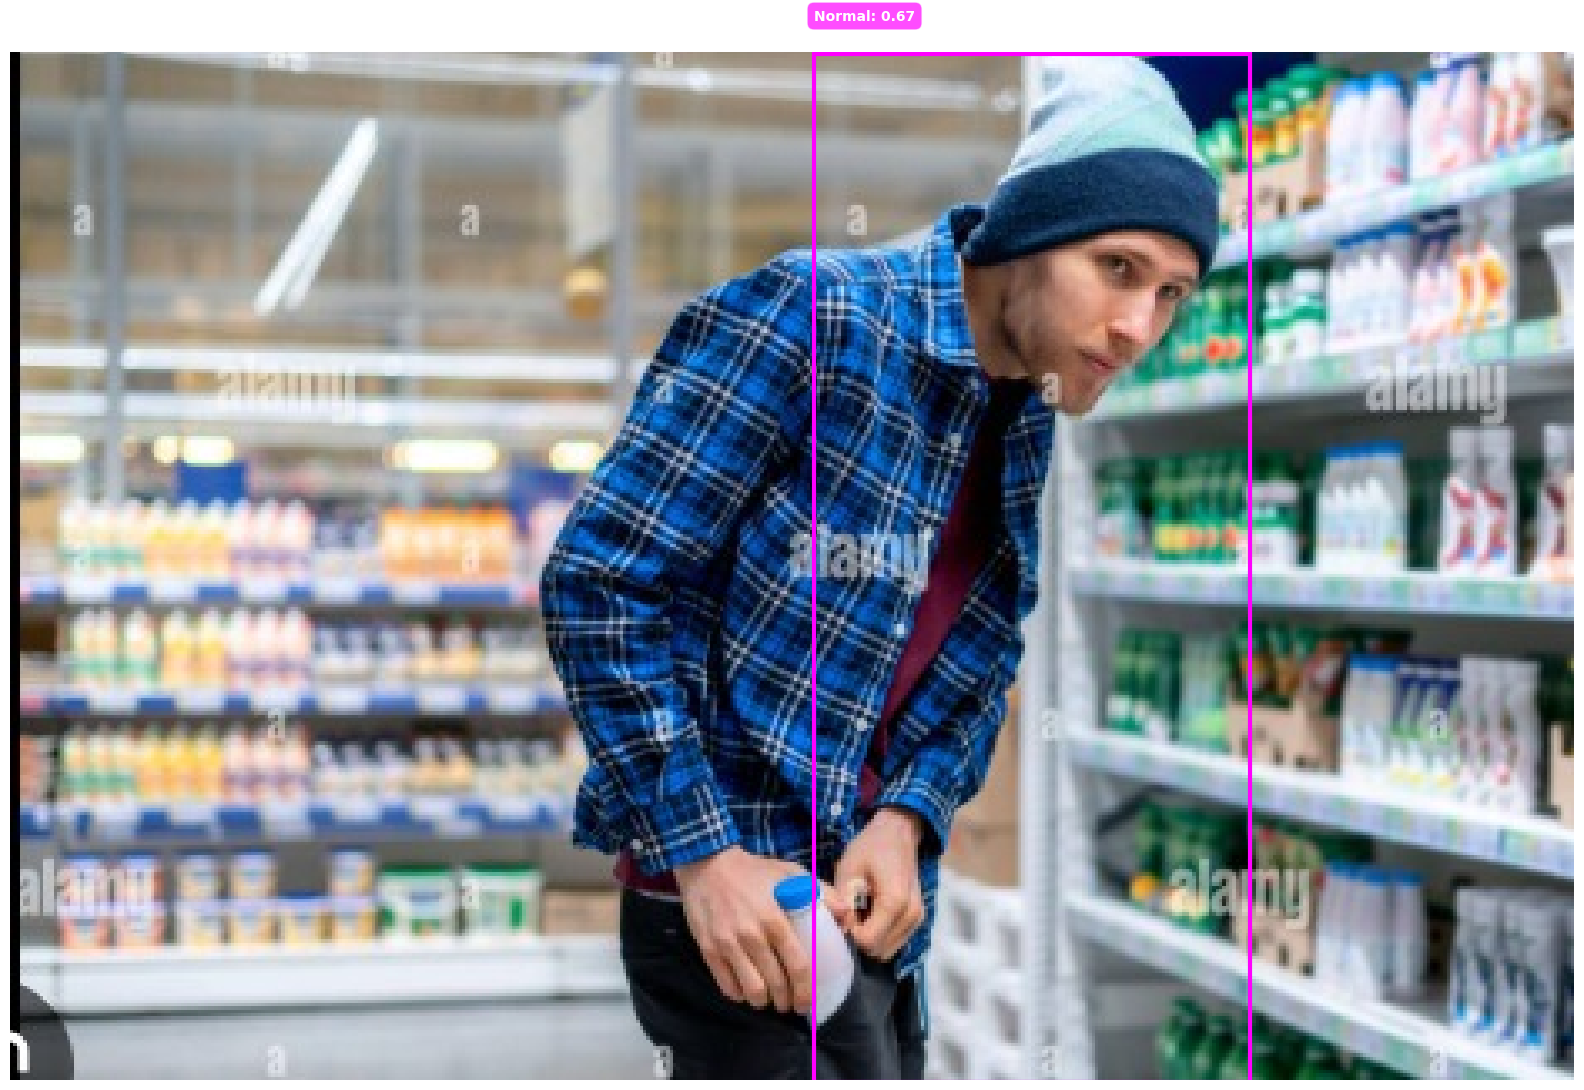


Testing complete!


In [54]:
# ============================================
# TEST UNSEEN IMAGE WITH ENSEMBLE (NO LABELS NEEDED)
# ============================================
import os
import cv2
import torch
import numpy as np
from ultralytics import YOLO
from torchvision.ops import nms
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ============================================
# CONFIGURATION
# ============================================
# Model paths (update these to match your paths)
MODEL_PATHS = {
    "yolov8n": "/content/drive/MyDrive/yolo_ensemble_project/yolov8n/weights/best.pt",
    "yolov8s": "/content/drive/MyDrive/yolo_ensemble_project/yolov8s/weights/best.pt",
    "yolov8m": "/content/drive/MyDrive/yolo_ensemble_project/yolov8m/weights/best.pt"
}

# Test image path (update this to your new unseen image)
TEST_IMAGE_PATH = "/content/drive/MyDrive/yolo_dataset/test_2.jpeg"

# Class names
CLASS_NAMES = [
    "Customer-Bagpack",
    "Product",
    "Product-Picked",
    "Shopping-Cart",
    "Normal",
    "Theft"
]

# Thresholds
CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.5

# Colors for visualization (RGB format)
COLORS = [
    (255, 0, 0),      # Customer-Bagpack - Red
    (0, 255, 0),      # Product - Green
    (0, 0, 255),      # Product-Picked - Blue
    (255, 255, 0),    # Shopping-Cart - Yellow
    (255, 0, 255),    # Normal - Magenta
    (0, 255, 255)     # Theft - Cyan
]

# ============================================
# HELPER FUNCTIONS
# ============================================

def ensemble_single_image(model_results, iou_thr=0.5, conf_thr=0.25):
    """
    Ensemble predictions from multiple models for a single image using NMS.

    Args:
        model_results: List of YOLO prediction results from different models
        iou_thr: IoU threshold for NMS
        conf_thr: Confidence threshold

    Returns:
        boxes, scores, labels (torch tensors)
    """
    boxes_all, scores_all, labels_all = [], [], []

    for res in model_results:
        if res is None or res.boxes is None or len(res.boxes) == 0:
            continue

        boxes = res.boxes.xyxy.cpu()
        scores = res.boxes.conf.cpu()
        labels = res.boxes.cls.cpu()

        # Filter by confidence
        keep = scores > conf_thr
        if keep.sum() == 0:
            continue

        boxes_all.append(boxes[keep])
        scores_all.append(scores[keep])
        labels_all.append(labels[keep])

    if len(boxes_all) == 0:
        return torch.empty((0, 4)), torch.empty(0), torch.empty(0)

    boxes = torch.cat(boxes_all)
    scores = torch.cat(scores_all)
    labels = torch.cat(labels_all)

    # Apply NMS
    keep = nms(boxes, scores, iou_thr)

    return boxes[keep], scores[keep], labels[keep]


def visualize_predictions(image_path, boxes, scores, labels, class_names, colors):
    """
    Visualize predictions on the image.

    Args:
        image_path: Path to the image
        boxes: Predicted boxes [N, 4] (x1, y1, x2, y2)
        scores: Confidence scores [N]
        labels: Class labels [N]
        class_names: List of class names
        colors: List of colors for each class (RGB)
    """
    # Read image
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Create figure
    fig, ax = plt.subplots(1, figsize=(16, 12))
    ax.imshow(img_rgb)

    # Draw each detection
    for box, score, label in zip(boxes, scores, labels):
        x1, y1, x2, y2 = box.cpu().numpy() if torch.is_tensor(box) else box
        cls_idx = int(label.item() if torch.is_tensor(label) else label)
        conf = float(score.item() if torch.is_tensor(score) else score)

        # Get class name and color
        cls_name = class_names[cls_idx] if cls_idx < len(class_names) else f"Class_{cls_idx}"
        color = np.array(colors[cls_idx]) / 255.0  # Normalize to [0, 1] for matplotlib

        # Draw rectangle
        width = x2 - x1
        height = y2 - y1
        rect = Rectangle((x1, y1), width, height,
                        linewidth=3, edgecolor=color, facecolor='none')
        ax.add_patch(rect)

        # Add label with background
        label_text = f"{cls_name}: {conf:.2f}"
        ax.text(x1, y1 - 10, label_text,
               bbox=dict(boxstyle='round,pad=0.5', facecolor=color, alpha=0.7),
               fontsize=10, color='white', weight='bold')

    ax.axis('off')
    plt.tight_layout()
    plt.show()


def print_detection_summary(boxes, scores, labels, class_names):
    """
    Print a detailed summary of all detections.
    """
    print("\n" + "="*60)
    print("DETECTION SUMMARY")
    print("="*60)

    if len(boxes) == 0:
        print("\nNo objects detected!")
        return

    # Count detections per class
    class_counts = {}
    for label in labels:
        cls_idx = int(label.item() if torch.is_tensor(label) else label)
        cls_name = class_names[cls_idx] if cls_idx < len(class_names) else f"Class_{cls_idx}"
        class_counts[cls_name] = class_counts.get(cls_name, 0) + 1

    print(f"\nTotal detections: {len(boxes)}")
    print("\nDetections by class:")
    for cls_name, count in sorted(class_counts.items()):
        print(f"  {cls_name}: {count}")

    print("\n" + "-"*60)
    print("Detailed detections:")
    print("-"*60)

    # Sort by confidence (highest first)
    sorted_indices = torch.argsort(scores, descending=True)

    for i, idx in enumerate(sorted_indices):
        box = boxes[idx]
        score = scores[idx]
        label = labels[idx]

        x1, y1, x2, y2 = box.cpu().numpy() if torch.is_tensor(box) else box
        cls_idx = int(label.item() if torch.is_tensor(label) else label)
        conf = float(score.item() if torch.is_tensor(score) else score)
        cls_name = class_names[cls_idx] if cls_idx < len(class_names) else f"Class_{cls_idx}"

        print(f"\n  Detection #{i+1}:")
        print(f"    Class: {cls_name}")
        print(f"    Confidence: {conf:.4f}")
        print(f"    Box: ({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})")
        print(f"    Size: {x2-x1:.1f} x {y2-y1:.1f} pixels")


# ============================================
# MAIN TEST CODE
# ============================================

print("="*60)
print("TESTING UNSEEN IMAGE WITH ENSEMBLE")
print("="*60)

# Load the image
print(f"\nLoading image: {TEST_IMAGE_PATH}")
img = cv2.imread(TEST_IMAGE_PATH)
if img is None:
    raise FileNotFoundError(f"Could not load image: {TEST_IMAGE_PATH}")

h, w = img.shape[:2]
print(f"Image dimensions: {w}x{h}")

# Load models and run predictions
print("\n" + "-"*60)
print("Running predictions from each model...")
print("-"*60)

model_results = []
individual_detections = {}

for model_name, model_path in MODEL_PATHS.items():
    print(f"\nLoading {model_name}...")
    model = YOLO(model_path)

    print(f"Running inference with {model_name}...")
    results = model.predict(
        source=TEST_IMAGE_PATH,
        conf=CONF_THRESHOLD,
        iou=IOU_THRESHOLD,
        save=False,
        verbose=False
    )

    model_results.append(results[0])

    # Show individual model results
    if results[0].boxes is not None:
        num_detections = len(results[0].boxes)
        individual_detections[model_name] = num_detections
        print(f"  {model_name} detected: {num_detections} objects")
    else:
        individual_detections[model_name] = 0
        print(f"  {model_name} detected: 0 objects")

# Run ensemble
print("\n" + "="*60)
print("RUNNING ENSEMBLE FUSION")
print("="*60)

ensemble_boxes, ensemble_scores, ensemble_labels = ensemble_single_image(
    model_results,
    iou_thr=IOU_THRESHOLD,
    conf_thr=CONF_THRESHOLD
)

print(f"\nIndividual model detections:")
for model_name, count in individual_detections.items():
    print(f"  {model_name}: {count}")

print(f"\nAfter ensemble fusion: {len(ensemble_boxes)} objects")
print(f"Reduction: {sum(individual_detections.values())} → {len(ensemble_boxes)} detections")

# Print detailed detection summary
print_detection_summary(ensemble_boxes, ensemble_scores, ensemble_labels, CLASS_NAMES)

# Visualize results
print("\n" + "="*60)
print("VISUALIZING RESULTS")
print("="*60)

if len(ensemble_boxes) > 0:
    visualize_predictions(
        TEST_IMAGE_PATH,
        ensemble_boxes,
        ensemble_scores,
        ensemble_labels,
        CLASS_NAMES,
        COLORS
    )
else:
    print("\nNo detections to visualize.")
    # Still show the image
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(16, 12))
    plt.imshow(img_rgb)
    plt.title("No detections found", fontsize=16)
    plt.axis('off')
    plt.show()

print("\n" + "="*60)
print("Testing complete!")
print("="*60)

